# BÀI TẬP THỰC HÀNH PHÂN TÍCH DỮ LIỆU

#Phần 1: Khởi tạo và Đọc dữ liệu

1. Import các thư viện cần thiết (pandas, matplotlib.pyplot) và đọc file dữ liệu
ecommerce_sales_data.csv vào một DataFrame có tên là df.

2. Hiển thị 7 dòng đầu tiên và 5 dòng cuối cùng của tập dữ liệu để có cái nhìn tổng quan.

3. Sử dụng phương thức thích hợp để in ra thông tin tổng quan của cấu trúc dữ liệu (số lượng
dòng, số lượng cột, kiểu dữ liệu của từng cột).

4. Sử dụng hàm thống kê mô tả để hiển thị các chỉ số cơ bản (trung bình, độ lệch chuẩn, min,
max...) của các cột dữ liệu dạng số.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1/
print("1: Đọc dữ liệu")
df = pd.read_excel("ecommerce_sales_data.xlsx")

# 2/
print("\n2: Hiển thị 7 dòng đầu và 5 dòng cuối")

print("\n7 dòng đầu tiên:")
print(df.head(7))

print("\n5 dòng cuối cùng:")
print(df.tail(5))

# 3/
print("\n3: Thông tin tổng quan của DataFrame")
df.info()

# 4/
print("\n4: Thống kê mô tả các cột dữ liệu số")
print(df.describe())

1: Đọc dữ liệu

2: Hiển thị 7 dòng đầu và 5 dòng cuối

7 dòng đầu tiên:
   OrderID        Date CustomerID Product_Category            Product_Name  \
0  ORD0001  2025-11-24    CUST027         Clothing                   Jeans   
1  ORD0002  2025-02-27    CUST025      Electronics              Smartphone   
2  ORD0003  2025-01-13    CUST025            Books  Machine Learning Intro   
3  ORD0004  2025-05-21    CUST002   Home & Kitchen            Coffee Maker   
4  ORD0005  2025-05-06    CUST008      Electronics                  Laptop   
5  ORD0006  2025-04-25    CUST027      Electronics                  Laptop   
6  ORD0007  2025-03-13    CUST002            Books   Data Science Handbook   

   Quantity  UnitPrice  Discount   Region  
0         6      93.20      0.12  Central  
1        10     134.67       NaN    South  
2         9     178.20      0.04    North  
3         3     199.86      0.01    North  
4         7     144.85      0.17    North  
5         3     138.23       NaN  Centr

#Phần 2: Khám phá và Làm sạch dữ liệu

1. Kiểm tra xem mỗi cột trong tập dữ liệu có bao nhiêu giá trị bị thiếu (NaN/Null).

2. Tiến hành xử lý giá trị thiếu ở cột Discount: Thay thế tất cả các giá trị bị thiếu bằng 0 (giả định đơn hàng không áp dụng giảm giá).

3. Tiến hành xử lý giá trị thiếu ở cột CustomerID: Thay thế tất cả các giá trị bị thiếu bằng chuỗi
ký tự 'GUEST'.
4. Kiểm tra lại để đảm bảo tập dữ liệu không còn giá trị bị thiếu nào.
5. Chuyển đổi kiểu dữ liệu của cột Date từ chuỗi (object) sang kiểu dữ liệu thời gian
(datetime).
6. Kiểm tra xem có dữ liệu nào bị trùng lặp toàn bộ thông tin trên các cột không. Nếu có, hãy tiến hành loại bỏ các dòng trùng lặp đó.

In [8]:
# 1/
print("1: Kiểm tra số lượng giá trị thiếu trên từng cột")
print(df.isnull().sum())

# 2/
print("\n2: Thay thế giá trị thiếu ở cột Discount bằng 0")

print("Số giá trị thiếu trước:", df["Discount"].isnull().sum())
df["Discount"] = df["Discount"].fillna(0)
print("Số giá trị thiếu sau:", df["Discount"].isnull().sum())

# 3/
print("\n3: Thay thế giá trị thiếu ở cột CustomerID bằng 'GUEST'")

print("Số giá trị thiếu trước:", df["CustomerID"].isnull().sum())
df["CustomerID"] = df["CustomerID"].fillna("GUEST")
print("Số giá trị thiếu sau:", df["CustomerID"].isnull().sum())

# 4/
print("\n4: Kiểm tra lại giá trị thiếu sau khi xử lý")
print(df.isnull().sum())

# 5/
print("\n5: Chuyển đổi cột Date sang kiểu datetime")
df["Date"] = pd.to_datetime(df["Date"])

# 6/
print("\n6: Kiểm tra và loại bỏ dữ liệu trùng lặp")

print("Số dòng trùng lặp:", df.duplicated().sum())

df = df.drop_duplicates()

print("Số dòng sau khi loại bỏ trùng lặp:", len(df))

1: Kiểm tra số lượng giá trị thiếu trên từng cột
OrderID              0
Date                 0
CustomerID           5
Product_Category     0
Product_Name         0
Quantity             0
UnitPrice            0
Discount            35
Region               0
dtype: int64

2: Thay thế giá trị thiếu ở cột Discount bằng 0
Số giá trị thiếu trước: 35
Số giá trị thiếu sau: 0

3: Thay thế giá trị thiếu ở cột CustomerID bằng 'GUEST'
Số giá trị thiếu trước: 5
Số giá trị thiếu sau: 0

4: Kiểm tra lại giá trị thiếu sau khi xử lý
OrderID             0
Date                0
CustomerID          0
Product_Category    0
Product_Name        0
Quantity            0
UnitPrice           0
Discount            0
Region              0
dtype: int64

5: Chuyển đổi cột Date sang kiểu datetime

6: Kiểm tra và loại bỏ dữ liệu trùng lặp
Số dòng trùng lặp: 0
Số dòng sau khi loại bỏ trùng lặp: 100


#Phần 3: Trích xuất và Biến đổi dữ liệu (Feature Engineering)
1. Tạo một cột mới tên là Revenue (Doanh thu). Biết công thức tính là:
Revenue = Quantity * UnitPrice * (1 - Discount).
2. Trích xuất Năm (Year) từ cột Date và lưu vào một cột mới tên là Year.
3. Trích xuất Tháng (Month) từ cột Date và lưu vào một cột mới tên là Month.
4. Trích xuất Ngày trong tuần (Day of Week) từ cột Date và lưu vào một cột mới tên là DayOfWeek (Hiển thị dưới dạng số hoặc tên ngày đều được).
5. Tạo một cột phân loại có tên là Price_Segment dựa trên đơn giá (UnitPrice) của sản phẩm: - 'High' nếu UnitPrice >= 150. - 'Medium' nếu 50 <= UnitPrice < 150. - 'Low' nếu UnitPrice < 50.

In [9]:
# 1/
print("1: Tạo cột Revenue")
df["Revenue"] = df["Quantity"] * df["UnitPrice"] * (1 - df["Discount"])
print(df[["Quantity", "UnitPrice", "Discount", "Revenue"]].head())

# 2/
print("\n2: Trích xuất Năm từ cột Date")
df["Year"] = df["Date"].dt.year
print(df[["Date", "Year"]].head())

# 3/
print("\n3: Trích xuất Tháng từ cột Date")
df["Month"] = df["Date"].dt.month
print(df[["Date", "Month"]].head())

# 4/
print("\n4: Trích xuất Ngày trong tuần từ cột Date")
df["DayOfWeek"] = df["Date"].dt.day_name()
print(df[["Date", "DayOfWeek"]].head())

# 5/
print("\n5: Tạo cột Price_Segment")
def classify_price(price):
    if price >= 150:
        return "High"
    elif price >= 50:
        return "Medium"
    else:
        return "Low"

df["Price_Segment"] = df["UnitPrice"].apply(classify_price)
print(df[["UnitPrice", "Price_Segment"]].head())

1: Tạo cột Revenue
   Quantity  UnitPrice  Discount    Revenue
0         6      93.20      0.12   492.0960
1        10     134.67      0.00  1346.7000
2         9     178.20      0.04  1539.6480
3         3     199.86      0.01   593.5842
4         7     144.85      0.17   841.5785

2: Trích xuất Năm từ cột Date
        Date  Year
0 2025-11-24  2025
1 2025-02-27  2025
2 2025-01-13  2025
3 2025-05-21  2025
4 2025-05-06  2025

3: Trích xuất Tháng từ cột Date
        Date  Month
0 2025-11-24     11
1 2025-02-27      2
2 2025-01-13      1
3 2025-05-21      5
4 2025-05-06      5

4: Trích xuất Ngày trong tuần từ cột Date
        Date  DayOfWeek
0 2025-11-24     Monday
1 2025-02-27   Thursday
2 2025-01-13     Monday
3 2025-05-21  Wednesday
4 2025-05-06    Tuesday

5: Tạo cột Price_Segment
   UnitPrice Price_Segment
0      93.20        Medium
1     134.67        Medium
2     178.20          High
3     199.86          High
4     144.85        Medium


#Phần 4: Lọc và Truy vấn dữ liệu
1. Lọc và hiển thị danh sách các đơn hàng thuộc khu vực 'North' có doanh thu (Revenue) lớn hơn 300.

2. Có bao nhiêu đơn hàng mua sản phẩm thuộc danh mục 'Electronics' mà hoàn toàn
không được giảm giá (Discount = 0)?

3. Lọc ra danh sách các đơn hàng mua trong khoảng thời gian từ tháng 3 đến tháng 6 của năm.

4. Chỉ hiển thị các cột OrderID, Product_Name, và Revenue cho 10 đơn hàng có doanh thu cao nhất.

5. Tìm và hiển thị thông tin chi tiết của đơn hàng có số lượng (Quantity) mua nhiều nhất trong một lần giao dịch.

In [11]:
# 1/
print("1: Đơn hàng thuộc khu vực North có Revenue > 300")
north_orders = df[(df["Region"] == "North") & (df["Revenue"] > 300)]
print(north_orders)

# 2/
print("\n2: Số đơn hàng Electronics không được giảm giá")
electronics_no_discount = df[
    (df["Product_Category"] == "Electronics") &
    (df["Discount"] == 0)
]
print("Số đơn hàng:", len(electronics_no_discount))

# 3/
print("\n3: Đơn hàng mua trong khoảng từ tháng 3 đến tháng 6")
orders_mar_jun = df[df["Month"].between(3, 6)]
print(orders_mar_jun)

# 4/
print("\n4: Top 10 đơn hàng có doanh thu cao nhất")
top10_revenue = df.nlargest(10, "Revenue")[
    ["OrderID", "Product_Name", "Revenue"]
]

print(top10_revenue)

# 5/
print("\n5: Đơn hàng có số lượng mua nhiều nhất")
max_quantity_order = df.loc[df["Quantity"].idxmax()]
print(max_quantity_order)

1: Đơn hàng thuộc khu vực North có Revenue > 300
    OrderID       Date CustomerID Product_Category              Product_Name  \
2   ORD0003 2025-01-13    CUST025            Books    Machine Learning Intro   
3   ORD0004 2025-05-21    CUST002   Home & Kitchen              Coffee Maker   
4   ORD0005 2025-05-06    CUST008      Electronics                    Laptop   
25  ORD0026 2025-10-07      GUEST            Books     Data Science Handbook   
31  ORD0032 2025-01-04    CUST018      Electronics                Headphones   
33  ORD0034 2025-12-24    CUST009      Electronics                Headphones   
36  ORD0037 2025-05-23    CUST014      Electronics                   Monitor   
37  ORD0038 2025-03-21    CUST029      Electronics                Smartphone   
44  ORD0045 2025-07-03    CUST016         Clothing                   T-Shirt   
45  ORD0046 2025-06-26    CUST003            Books  Python for Data Analysis   
51  ORD0052 2025-03-05    CUST021   Home & Kitchen              Coffee 

#Phần 5: Phân tích, Gom nhóm và Tổng hợp
1. Nhóm dữ liệu theo khu vực (Region) và tính tổng doanh thu (Revenue) của từng khu vực.

2. Theo bạn, khu vực nào mang lại doanh thu cao nhất?

3. Tính trung bình số lượng (Quantity) và đơn giá (UnitPrice) của sản phẩm được bán ra theo từng Danh mục sản phẩm (Product_Category).

4. Thống kê tổng số lượng đơn hàng (chỉ cần đếm số dòng) theo từng tháng. Tháng nào ghi nhận số lượng đơn hàng mua nhiều nhất?

5. Tìm ra Top 3 khách hàng (CustomerID, loại trừ khách hàng 'GUEST') có tổng mức chi tiêu (tổng Revenue) cao nhất.

In [12]:
# 1/
print("1: Tổng doanh thu theo từng khu vực")
revenue_by_region = df.groupby("Region")["Revenue"].sum()
print(revenue_by_region)

# 2/
print("\n2: Khu vực có doanh thu cao nhất")
top_region = revenue_by_region.idxmax()
top_revenue = revenue_by_region.max()
print("Khu vực:", top_region)
print("Tổng doanh thu:", top_revenue)

# 3/
print("\n3: Trung bình Quantity và UnitPrice theo Product_Category")

category_stats = df.groupby("Product_Category")[
    ["Quantity", "UnitPrice"]
].mean()
print(category_stats)

# 4/
print("\n4: Tổng số lượng đơn hàng theo từng tháng")
orders_by_month = df.groupby("Month").size()
print(orders_by_month)
print("\nTháng có nhiều đơn hàng nhất:")
print("Tháng:", orders_by_month.idxmax())
print("Số đơn hàng:", orders_by_month.max())

# 5/
print("\n5: Top 3 khách hàng có tổng mức chi tiêu cao nhất")
top_customers = (
    df[df["CustomerID"] != "GUEST"]
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)
print(top_customers)

1: Tổng doanh thu theo từng khu vực
Region
Central    30679.9509
North      23579.3016
South      18995.3702
Name: Revenue, dtype: float64

2: Khu vực có doanh thu cao nhất
Khu vực: Central
Tổng doanh thu: 30679.9509

3: Trung bình Quantity và UnitPrice theo Product_Category
                  Quantity   UnitPrice
Product_Category                      
Books             5.071429  124.435000
Clothing          5.321429  167.446786
Electronics       5.551724  166.513103
Home & Kitchen    4.620690  141.211724

4: Tổng số lượng đơn hàng theo từng tháng
Month
1      7
2     12
3      7
4     11
5     11
6      4
7      9
8      7
9      1
10    10
11    11
12    10
dtype: int64

Tháng có nhiều đơn hàng nhất:
Tháng: 2
Số đơn hàng: 12

5: Top 3 khách hàng có tổng mức chi tiêu cao nhất
CustomerID
CUST025    5505.3496
CUST004    5033.4404
CUST017    4553.5066
Name: Revenue, dtype: float64


#Phần 6: Trực quan hóa dữ liệu cơ bản
1. Sử dụng matplotlib hoặc seaborn để vẽ một biểu đồ cột (Bar chart) thể hiện tổng
doanh thu theo từng Danh mục sản phẩm (Product_Category). Nhớ thêm tiêu đề, nhãn
cho trục X và Y.

2. Vẽ biểu đồ đường (Line chart) thể hiện sự biến động của tổng doanh thu hệ thống qua các tháng trong năm.

1: Biểu đồ cột tổng doanh thu theo danh mục sản phẩm


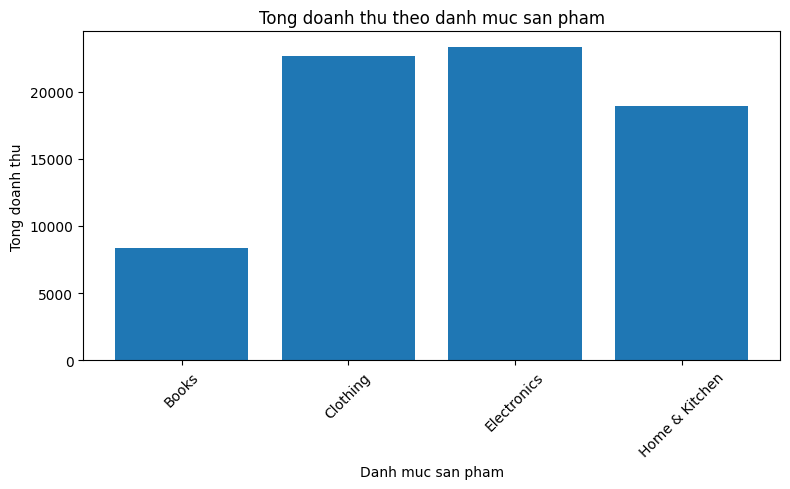


2: Biểu đồ đường thể hiện doanh thu theo tháng


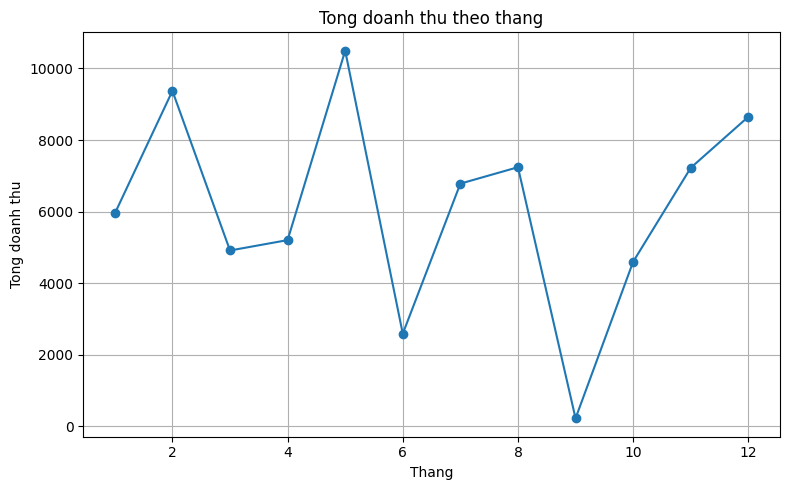

In [13]:
# 1/
print("1: Biểu đồ cột tổng doanh thu theo danh mục sản phẩm")
revenue_by_category = df.groupby("Product_Category")["Revenue"].sum()
plt.figure(figsize=(8, 5))
plt.bar(revenue_by_category.index, revenue_by_category.values)
plt.title("Tong doanh thu theo danh muc san pham")
plt.xlabel("Danh muc san pham")
plt.ylabel("Tong doanh thu")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2/
print("\n2: Biểu đồ đường thể hiện doanh thu theo tháng")
monthly_revenue = df.groupby("Month")["Revenue"].sum().sort_index()
plt.figure(figsize=(8, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.title("Tong doanh thu theo thang")
plt.xlabel("Thang")
plt.ylabel("Tong doanh thu")
plt.grid(True)
plt.tight_layout()
plt.show()